# 电影情感分类实战_LSTM_双层单向/双向

In [1]:
from datasets import load_dataset

# 加载数据集
dataset = load_dataset('imdb')

# 查看数据集
print("数据集基本信息：\n", dataset)

# 查看数据集的第一个样本
print("\n数据集的第一个样本：\n", dataset['train'][0])

c:\Users\MSI-NB\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


数据集基本信息：
 DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

数据集的第一个样本：
 {'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between

## 读取数据，word-level 分词，构建词典

In [2]:
import re
from collections import Counter

# 读取训练集数据
train_texts = dataset['train']['text']

# 定义简单的分词函数，按单词切分（小写，去除非字母数字字符）
def word_tokenize(text):
    # 将文本小写，只保留字母和数字
    # '\b' 表示单词边界，\w+ 表示一个或多个字母、数字或下划线
    # text.lower() 将文本转换为小写作为返回值
    words = re.findall(r'\b\w+\b', text.lower())
    return words

# 对所有文本进行分词
tokenized_texts = [word_tokenize(text) for text in train_texts]

# print(type(tokenized_texts))  # 输出 list
# print(type(tokenized_texts[0]))  # 输出 list
# print(type(tokenized_texts[0][0]))  # 输出 str
# tokenized_texts是嵌套的列表
# 直接传入Counter 进行统计仅适用于数据已经是扁平结构或统计对象是整句/标签的情况
# 如果数据是嵌套结构，需要先展平数据

# 构建词典（词频统计）
word_counter = Counter()

for tokens in tokenized_texts:
    word_counter.update(tokens)

# 生成词典：word2idx, 假设保留最常见的 20000 个词，idx 从1开始，0用于<pad>
vocab_size = 20000

# most_common 返回一个列表，列表中每个元素是一个元组
# 元组中第一个元素是单词，第二个元素是词频
# 列表中元组按词频从高到低排序
most_common_words = [word for word, freq in word_counter.most_common(vocab_size)]  # 获取最常见的20000个词

# 添加特殊符号
# <pad> 填充符号， <unk> 未知符号， <bos> 开始符号， <eos> 结束符号
most_common_words_spical = ['<pad>', '<unk>', '<bos>', '<eos>'] + most_common_words

# 建立word2idx 和 idx2word 字典映射
word2idx = {word: idx for idx, word in enumerate(most_common_words_spical)}
idx2word = {idx: word for word, idx in word2idx.items()}

# 查看前10个词和索引
print("前10个词和索引：", list(word2idx.items())[:10])


前10个词和索引： [('<pad>', 0), ('<unk>', 1), ('<bos>', 2), ('<eos>', 3), ('the', 4), ('and', 5), ('a', 6), ('of', 7), ('to', 8), ('is', 9)]


样本总数: 25000
最短的样本长度: 10
最长的样本长度: 2525
平均样本长度: 242.27
中位数样本长度: 181.0
样本长度标准差: 179.87


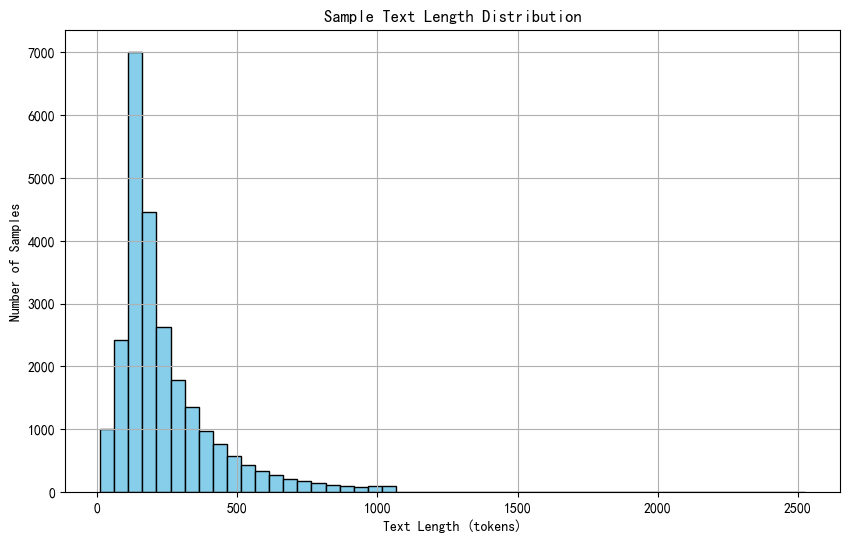

In [3]:
# 统计train_texts每条样本的长度（分词后）
sample_lengths = [len(text) for text in tokenized_texts]

# 打印关键信息
print(f"样本总数: {len(tokenized_texts)}")
print(f"最短的样本长度: {min(sample_lengths)}")
print(f"最长的样本长度: {max(sample_lengths)}")
print(f"平均样本长度: {sum(sample_lengths)/len(sample_lengths):.2f}")
import numpy as np
print(f"中位数样本长度: {np.median(sample_lengths)}")
print(f"样本长度标准差: {np.std(sample_lengths):.2f}")

# 绘图显示分布
import matplotlib.pyplot as plt

# 设置matplotlib支持中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定默认字体为黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号'-'显示为方块的问题

plt.figure(figsize=(10,6))
plt.hist(sample_lengths, bins=50, color='skyblue', edgecolor='black')
plt.title("Sample Text Length Distribution")
plt.xlabel("Text Length (tokens)")
plt.ylabel("Number of Samples")
plt.grid(True)
plt.show()



## 编写Tokenizer

encoder （编码）：把样本变成id

decoder （解码）：把id变成word

In [4]:
class Tokenizer:
    """一个简单的 word-level Tokenizer。

    你可以在初始化时设置默认控制参数（如是否加 BOS/EOS、是否 padding、是否 truncation 等），
    也可以在调用 `encode/decode` 时传参覆盖。
    """

    def __init__(
        self,
        word2idx: dict,
        idx2word: dict,
        tokenize_fn=word_tokenize,
        pad_token: str = '<pad>',
        unk_token: str = '<unk>',
        bos_token: str = '<bos>',
        eos_token: str = '<eos>',
        max_length: int | None = None,
        add_bos: bool = False,
        add_eos: bool = False,
        truncation: bool = True,
        skip_special_tokens: bool = True,
        stop_at_eos: bool = False,
    ):
        """
        初始化 Tokenizer。

        参数说明：
            word2idx (dict): 词到id的映射字典，例如 {'hello':1, ...}
            idx2word (dict): id到词的映射字典，例如 {1:'hello', ...}
            tokenize_fn (callable): 分词函数，输入为字符串，输出为token（词）列表，默认 word_tokenize。
            pad_token (str): 用于补齐长度的特殊符号字符串（默认为'<pad>'），应包含于 word2idx 中。
            unk_token (str): 未知词特殊符号（默认为'<unk>'），应包含于 word2idx 中。
            bos_token (str): 序列开始特殊符号（默认为'<bos>'），应包含于 word2idx 中。
            eos_token (str): 序列结束特殊符号（默认为'<eos>'），应包含于 word2idx 中。
            max_length (int|None): 默认编码输出最大长度，None表示不限长。
            add_bos (bool): 编码时是否自动在序列开头加 BOS。
            add_eos (bool): 编码时是否自动在序列结尾加 EOS。
            truncation (bool): 超长度时是否截断。
            skip_special_tokens (bool): 解码时是否跳过输出特殊符号。
            stop_at_eos (bool): 解码遇到 <eos> 时是否立刻停止解码（不包含eos）。
        """
        self.word2idx = word2idx
        self.idx2word = idx2word
        self.tokenize_fn = tokenize_fn

        # 特殊符号
        self.pad_token = pad_token
        self.unk_token = unk_token
        self.bos_token = bos_token
        self.eos_token = eos_token

        # 特殊符号对应 id
        self.pad_id = self.word2idx[self.pad_token]
        self.unk_id = self.word2idx[self.unk_token]
        self.bos_id = self.word2idx[self.bos_token]
        self.eos_id = self.word2idx[self.eos_token]

        # 默认控制参数（调用时若传 None，则使用这些默认值）
        self.max_length = max_length
        self.add_bos = add_bos
        self.add_eos = add_eos
        self.truncation = truncation
        self.skip_special_tokens = skip_special_tokens
        self.stop_at_eos = stop_at_eos

    def encode(
        self,
        texts: list[str],
        max_length: int | None = None,
        add_bos: bool | None = None,
        add_eos: bool | None = None,
        truncation: bool | None = None,
    ):
        """
        将文本编码为 id 序列。

        参数说明：
            texts (lsit[str]): 待编码的一批样本
            max_length (int|None): 目标id序列长度；为 None 时使用初始化的 max_length，若仍为 None，则不做截断或补齐。
            add_bos (bool|None): 是否添加 BOS（<bos>）特殊符号，None表示用类的默认设定。
            add_eos (bool|None): 是否添加 EOS（<eos>）特殊符号，None表示用类的默认设定。
            truncation (bool|None): 是否对超长的id序列截断至max_length，None用类默认值。

        返回：
            ids (List[int]): 编码后的id序列（按要求加上特殊符号/截断/补齐）。
        """
        # 若未传入则使用实例的默认参数
        if max_length is None:
            max_length = self.max_length
        if add_bos is None:
            add_bos = self.add_bos
        if add_eos is None:
            add_eos = self.add_eos
        if truncation is None:
            truncation = self.truncation

        batch_ids = []
        for text in texts:
            tokens = self.tokenize_fn(text)  # 用分词函数把文本拆成token(词)

            # token 映射到 id，不在词表里用unk_id
            ids = [self.word2idx.get(t, self.unk_id) for t in tokens]

            # 可选: 在序列开头/结尾加BOS/EOS
            if add_bos:
                ids = [self.bos_id] + ids
            if add_eos:
                ids = ids + [self.eos_id]

            batch_ids.append(ids)  # 把该样本的id序列加入batch_id列表

        # 根据 本批次样本的最大长度 和 max_length 中较小者进行截断和补齐
        max_len_in_batch = max(len(x) for x in batch_ids)  # 获取本批次样本的最大长度
        if max_length is not None:
            pad_len = min(max_len_in_batch, max_length)  # 取本批次样本最大长度和max_length中较小者
        else:
            pad_len = max_len_in_batch  # 若max_length为None，则取本批次样本最大长度

        padded_ids = []  # 存储填充后的id序列
        # 遍历本批次所有样本
        for ids in batch_ids:
            # 如果需要截断，则保留前pad_len个
            if truncation and len(ids) > pad_len:
                ids = ids[:pad_len]
            # 补齐：长度不足用pad_id填满
            if len(ids) < pad_len:
                ids = ids + [self.pad_id] * (pad_len - len(ids))
            padded_ids.append(ids)  # 将处理后的id序列添加到结果列表

        return padded_ids  # 返回token id列表，每个样本长度均为当前批次pad_len

    def decode(
        self,
        batch_ids,
        skip_special_tokens: bool | None = None,
        stop_at_eos: bool | None = None,
    ):
        """
        将 id 序列解码回文本。

        参数说明：
            batch_ids: List[List[int]]，2维列表，每个内部列表是一个样本的token ids
            skip_special_tokens (bool|None): 解码时是否跳过 <pad>/<unk>/<bos>/<eos>，即输出时不包含这些特殊符号。None采用实例默认值。
            stop_at_eos (bool|None): 解码时遇到 <eos> 是否马上停止（不再继续输出后续token），None采用实例默认值。

        返回：
            text (list[str]): 解码后的文本（token用空格拼接）。
        """
        # 用实例参数的默认值（如果没有明确传参）
        if skip_special_tokens is None:
            skip_special_tokens = self.skip_special_tokens
        if stop_at_eos is None:
            stop_at_eos = self.stop_at_eos

        # 需要跳过的特殊id集合
        special_ids = {self.pad_id, self.unk_id, self.bos_id, self.eos_id} if skip_special_tokens else set()

        results = []
        for ids in batch_ids:
            if hasattr(ids, 'tolist'):  # for torch.Tensor，对tensor转为list
                ids = ids.tolist()
            
            words = []
            for i in ids:
                # 可选: 解码遇到eos时立即停止
                if stop_at_eos and i == self.eos_id:
                    break
                # 若需跳过特殊符号则不输出
                if i in special_ids:
                    continue
                # id映射为词，若没在字典则输出unk_token
                words.append(self.idx2word.get(i, self.unk_token))

            results.append(' '.join(words)) # 用空格拼接所有words

        return results  # 返回每个样本解码后的字符串列表


**使用一个简单的示例测试 Tokenizer 类**

In [5]:
import random

# 先通过上面的类实例化 tokenizer 对象
tokenizer = Tokenizer(word2idx,idx2word,max_length=500,skip_special_tokens=False)  # 传入需要的参数

# 对每个样本encode
batch_token_ids = tokenizer.encode(train_texts[0:3])
print("\nencode后token id:")
for i, tids in enumerate(batch_token_ids):
    print(f"样本{i+1} token ids:", tids)
    print(f"样本{i+1} 长度:", len(tids))

print('-'*50)
decoded_texts = tokenizer.decode(batch_token_ids)
print("\ndecode后文本:")
for i, text in enumerate(decoded_texts):
    print(f"样本{i+1} 解码文本:", text)


encode后token id:
样本1 token ids: [13, 1611, 13, 247, 1996, 4105, 41, 63, 373, 1113, 89, 7, 34, 4, 7099, 15, 3401, 11, 57, 11, 17, 87, 624, 12, 6816, 13, 85, 556, 15, 35, 87, 11, 17, 19107, 37, 1189, 16, 9268, 49, 11, 127, 795, 8, 2522, 14, 666, 1621, 114, 6, 337, 7, 110, 1185, 3097, 13, 68, 71, 8, 69, 14, 19, 545, 10, 10, 4, 115, 9, 4003, 190, 6, 188, 3926, 455, 1426, 769, 4337, 39, 492, 8, 843, 288, 56, 54, 47, 113, 12, 836, 56, 492, 8, 1137, 44, 11901, 8, 232, 52, 435, 7, 653, 26, 51, 4, 844, 1, 199, 47, 804, 986, 1333, 143, 18, 4, 2553, 327, 5, 1508, 1333, 12, 4, 2339, 1616, 12, 202, 2249, 7279, 5, 1956, 19108, 7, 1, 47, 70, 4721, 26, 2409, 56, 50, 382, 20, 44, 455, 1712, 8187, 5, 1008, 339, 10, 10, 51, 1089, 74, 47, 13, 247, 1996, 4105, 9, 15, 1437, 158, 596, 14, 17, 1185, 7821, 68, 4, 382, 5, 999, 140, 29, 174, 5, 231, 202, 62, 96, 11, 16, 27, 326, 42, 52, 6477, 94, 4377, 139, 63, 1, 333, 172, 11, 1601, 12, 622, 382, 5, 999, 29, 6, 673, 10086, 12, 3926, 430, 62, 14259, 4451, 4676,

## DataSet 和Dataloader

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
from functools import partial

class IMDBDataset(Dataset):
    """IMDB 文本分类数据集，返回 (text, label)。"""
    def __init__(self, hf_dataset_split):
        # hf_dataset_split: HuggingFace 的一个切分，如 dataset['train']
        self.texts = hf_dataset_split['text']
        self.labels = hf_dataset_split['label']

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        # 返回原始文本和标签，真正的编码在 DataLoader 的 collate_fn 里做
        return self.texts[idx], self.labels[idx]


def collate_fn(batch, tokenizer: Tokenizer, max_length: int = 300):
    """DataLoader 的回调函数：把一批 (text, label) 打包成模型可直接使用的 tensor。

    参数：
    - batch: List[(text, label)]，DataLoader 自动传入
    - tokenizer: 上面实现的 Tokenizer 实例
    - max_length: 每个样本的最大长度

    返回：
    - input_ids: LongTensor，形状 [batch_size, seq_len]
    - labels: LongTensor，形状 [batch_size]
    """
    texts, labels = zip(*batch)              # 解包成两个 tuple
    # 使用我们自己的 tokenizer 进行批量编码
    batch_ids = tokenizer.encode(list(texts), max_length=max_length)
    input_ids = torch.tensor(batch_ids, dtype=torch.long)
    labels = torch.tensor(labels, dtype=torch.long)
    return input_ids, labels


# 创建 Dataset 实例（训练集和测试集）
train_dataset = IMDBDataset(dataset['train'])
test_dataset = IMDBDataset(dataset['test'])

# 训练集 DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    collate_fn=partial(collate_fn, tokenizer=tokenizer, max_length=500)  # 使用partial绑定参数
)

# 测试集 DataLoader（不打乱）
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=partial(collate_fn, tokenizer=tokenizer, max_length=500)
)

# 简单看一下一个训练 batch
for batch_idx, (input_ids, labels) in enumerate(train_loader):
    print("训练集第一个 batch 的 input_ids 形状:", input_ids.shape)
    print("训练集第一个 batch 的 labels:", labels)
    # 为了输出不要太长，只打印前两个样本前20个 token
    print("训练样本1前20个 token id:", input_ids[0][:20].tolist())
    print("训练样本2前20个 token id:", input_ids[1][:20].tolist())
    break

# 简单看一下一个测试 batch
for batch_idx, (input_ids, labels) in enumerate(test_loader):
    print("测试集第一个 batch 的 input_ids 形状:", input_ids.shape)
    print("测试集第一个 batch 的 labels:", labels)
    # 为了输出不要太长，只打印前两个样本前20个 token
    print("测试样本1前20个 token id:", input_ids[0][:20].tolist())
    print("测试样本2前20个 token id:", input_ids[1][:20].tolist())
    break


训练集第一个 batch 的 input_ids 形状: torch.Size([64, 500])
训练集第一个 batch 的 labels: tensor([0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1,
        1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1])
训练样本1前20个 token id: [10980, 12, 4, 3567, 4794, 72, 31, 6, 1681, 15, 291, 6, 196, 79, 21, 8421, 148, 2511, 4485, 16]
训练样本2前20个 token id: [1002, 2003, 4278, 9, 35, 30, 93, 2242, 5, 1444, 130, 18, 6, 566, 128, 5, 1705, 320, 39, 492]
测试集第一个 batch 的 input_ids 形状: torch.Size([64, 500])
测试集第一个 batch 的 labels: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
测试样本1前20个 token id: [13, 118, 910, 908, 5, 247, 1686, 8, 277, 59, 20, 6, 178, 910, 908, 102, 246, 29, 629, 1]
测试样本2前20个 token id: [293, 4, 711, 1101, 7, 6, 2354, 262, 49, 25, 42, 206, 102,

## 搭建模型_双层LSTM（默认单向，可切换双向）

In [7]:
import torch.nn as nn
import torch.nn.functional as F

class TextClassifier(nn.Module):
    """
    文本分类模型：Embedding -> Multi-layer LSTM -> Linear
    
    模型架构：
    1. Embedding层：将token id转换为词向量
    2. 多层LSTM层：处理序列信息，捕获长距离依赖（默认双层单向，可通过bidirectional参数切换为双向）
    3. 全连接层：将LSTM输出映射到分类结果
    
    多层LSTM优势：
    - 多层结构可以提取更抽象的特征表示
    - 第一层捕获局部特征，第二层捕获更全局的特征
    - 双向模式（可选）：同时考虑前向和后向信息，能够更好地理解上下文
    """
    def __init__(self, vocab_size, embedding_dim, num_classes, padding_idx, hidden_size=64, num_layers=2, bidirectional=False):
        """
        初始化文本分类模型（双层LSTM，默认单向）
        
        Args:
            vocab_size (int): 词表大小，即所有可能的token数量
            embedding_dim (int): 词向量维度，每个token被映射为多少维的向量
            num_classes (int): 分类类别数，IMDB数据集为2（正面/负面）
            padding_idx (int): 填充token的索引，用于忽略padding位置的计算
            hidden_size (int): LSTM隐藏层维度，默认64
                注意：双向LSTM的输出维度为 hidden_size * 2，单向为 hidden_size
            num_layers (int): LSTM层数，默认2层（双层LSTM）
            bidirectional (bool): 是否使用双向LSTM，默认False（单向）
        """
        super().__init__()
        
        # 保存bidirectional参数，用于forward方法中判断
        self.bidirectional = bidirectional
        self.num_layers = num_layers
        
        # 1. 词向量嵌入层（Embedding Layer）
        # 将每个token id映射为embedding_dim维的稠密向量
        # padding_idx参数确保填充位置的梯度不会被更新
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
        
        # 2. 多层LSTM层（Multi-layer Long Short-Term Memory）
        # 多层LSTM可以提取更抽象的特征：
        #   - 第一层：捕获局部序列特征
        #   - 第二层：基于第一层的输出，捕获更全局的特征
        # 输出维度说明：
        #   - 单向LSTM: output [batch_size, seq_len, hidden_size], hn [num_layers, batch_size, hidden_size]
        #   - 双向LSTM: output [batch_size, seq_len, hidden_size * 2], hn [num_layers * 2, batch_size, hidden_size]
        self.lstm = nn.LSTM(
            input_size=embedding_dim,      # 输入维度：词向量维度
            hidden_size=hidden_size,        # 每个方向的隐藏层维度
            num_layers=num_layers,          # LSTM层数（双层）
            batch_first=True,               # 批次维度在前
            bidirectional=bidirectional,     # 是否双向（默认False，单向）
        )
        
        # 3. 全连接分类层（Fully Connected Layers）
        # 根据bidirectional参数决定输入维度
        # 单向LSTM: hidden_size，双向LSTM: hidden_size * 2
        lstm_output_dim = hidden_size * 2 if bidirectional else hidden_size
        # 第一层：将LSTM输出映射到128维
        self.fc1 = nn.Linear(lstm_output_dim, 128)
        # ReLU激活函数：增加非线性，提高模型表达能力
        self.relu = nn.ReLU()
        # 第二层：将128维映射到类别数（二分类为1，使用sigmoid；多分类为类别数，使用softmax）
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, input_ids):
        """
        前向传播过程
        
        Args:
            input_ids (torch.LongTensor): token id序列，形状为 [batch_size, seq_len]
        
        Returns:
            logits (torch.Tensor): 分类logits，形状为 [batch_size, num_classes]
        """
        # Step 1: 词嵌入（Word Embedding）
        # 将token id转换为稠密向量表示
        # 输入: [batch_size, seq_len] -> 输出: [batch_size, seq_len, embedding_dim]
        x = self.embedding(input_ids)
        
        # Step 2: 多层LSTM前向传播
        # 双向LSTM同时处理前向和后向序列信息
        # output: [batch_size, seq_len, hidden_size * 2]
        #   - 每个时间步的输出是前向和后向隐藏状态的拼接
        # (hn, cn): 元组，包含最后一个时间步的状态
        #   - hn: [num_layers * 2, batch_size, hidden_size]
        #   - cn: [num_layers * 2, batch_size, hidden_size] - 记忆单元（cell state）
        output, (hn, cn) = self.lstm(x)
        
        # Step 3: 提取序列表示
        if self.bidirectional:
            # 双向LSTM：需要拼接前向和后向的最后一个隐藏状态
            # hn的形状: [num_layers * 2, batch_size, hidden_size]
            # 对于双层双向LSTM：
            #   - hn[0]: 第一层前向LSTM的隐藏状态 [batch_size, hidden_size]
            #   - hn[1]: 第一层后向LSTM的隐藏状态 [batch_size, hidden_size]
            #   - hn[2]: 第二层前向LSTM的隐藏状态 [batch_size, hidden_size]
            #   - hn[3]: 第二层后向LSTM的隐藏状态 [batch_size, hidden_size]
            # 通常使用最后一层（第二层）的隐藏状态
            forward_hidden = hn[-2]  # 最后一层前向 [batch_size, hidden_size]
            backward_hidden = hn[-1]  # 最后一层后向 [batch_size, hidden_size]
            # 在特征维度上拼接，得到 [batch_size, hidden_size * 2]
            last_hidden = torch.cat([forward_hidden, backward_hidden], dim=1)
            
            # 也可以直接使用output的最后一个时间步（结果相同）
            # last_hidden = output[:, -1, :]  # [batch_size, hidden_size * 2]
        else:
            # 单向LSTM：直接使用最后一层的隐藏状态
            # hn的形状: [num_layers, batch_size, hidden_size]
            # 对于双层单向LSTM，hn[-1]是第二层（最后一层）的隐藏状态
            last_hidden = hn[-1]  # [batch_size, hidden_size]
            
            # 也可以直接使用output的最后一个时间步（结果相同）
            # last_hidden = output[:, -1, :]  # [batch_size, hidden_size]
        
        # Step 4: 全连接层分类
        # 第一层全连接 + ReLU激活
        # 输入维度根据bidirectional自动调整
        x = self.fc1(last_hidden)  # [batch_size, lstm_output_dim] -> [batch_size, 128]
        x = self.relu(x)            # 非线性激活
        
        # 第二层全连接，输出分类logits
        # 输入: [batch_size, 128] -> 输出: [batch_size, num_classes]
        logits = self.fc2(x)
        
        return logits

In [8]:
# 前向计算验证模型
vocab_size = len(word2idx)
num_classes = 1  # IMDB 情感：0/1
embedding_dim = 16

model = TextClassifier(vocab_size=vocab_size,
                       embedding_dim=embedding_dim,
                       num_classes=num_classes,
                       padding_idx=word2idx['<pad>'])  # 填充索引

# 取一个 batch 测试前向传播
for batch_idx, (input_ids, labels) in enumerate(train_loader):
    print("input_ids 形状:", input_ids.shape)
    logits = model(input_ids)  # [B, num_classes]
    print("logits 形状:", logits.shape)
    print("示例 logits:", logits[0])
    break


input_ids 形状: torch.Size([64, 500])
logits 形状: torch.Size([64, 1])
示例 logits: tensor([0.0159], grad_fn=<SelectBackward0>)


## 模型训练及评估

Trainer 初始化完成
设备: cuda
损失函数: BCEWithLogitsLoss()
优化器: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
模型名称: imdb_text_embedding_multi_layer_LSTM_classifier
训练集: 25000 个样本, 391 个批次
验证集: 25000 个样本, 391 个批次
早停: 启用 (patience=5, monitor=val_acc, min_delta=0.001)
模型保存: 保存最佳模型 (保存目录: ./checkpoints/imdb_classification)
开始训练模型...

开始训练二分类模型
训练轮数: 40
训练集: 25000 个样本, 391 个批次
验证集: 25000 个样本, 391 个批次
设备: cuda
优化器: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
早停: 启用 (patience=5, monitor=val_acc, min_delta=0.001)
模型保存: 保存最佳模型 (保存目录: ./checkpoints/imdb_classification)

Epoch [1/40], Train Loss: 0.6934, Train Acc: 0.5001, Val Loss: 0.6932, Val Acc: 0.5033
Epoc

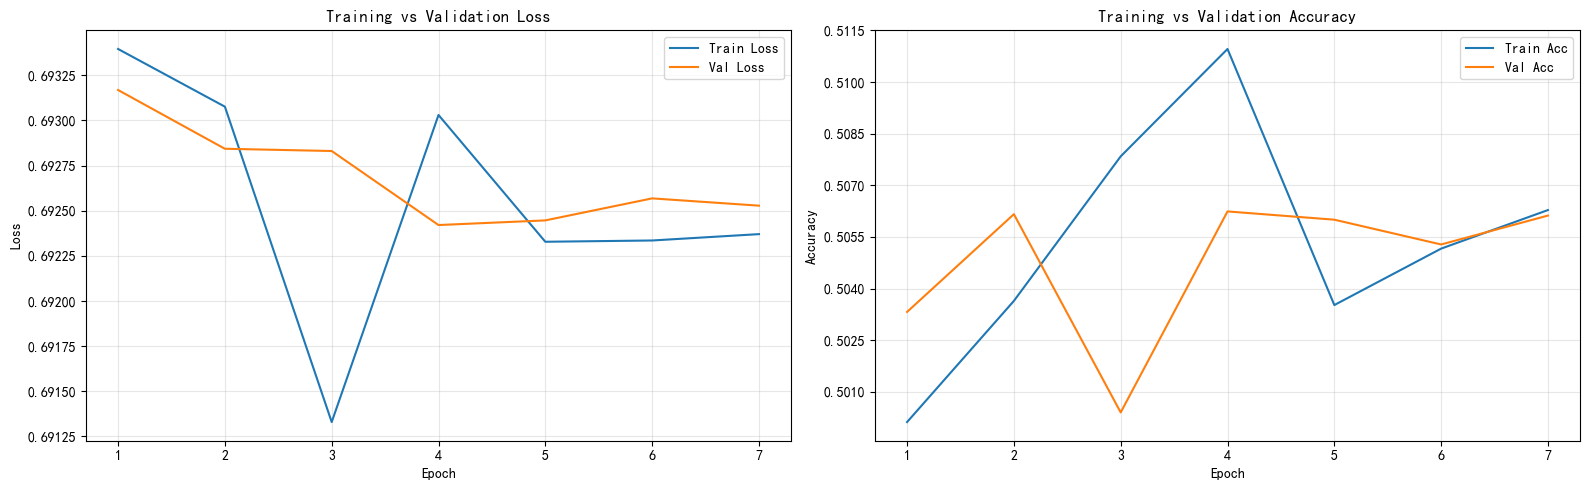

训练历史曲线绘制完成！


In [9]:
# 导入 Train_v5_2 模块
import sys
sys.path.append('.')
from Train_v5_2 import Trainer

# 导入必要的模块
import torch
import torch.nn as nn
import torch.optim as optim

# 创建模型实例
vocab_size = len(word2idx)
num_classes = 1  # IMDB 二分类：0/1
embedding_dim = 16

model = TextClassifier(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    num_classes=num_classes,
    padding_idx=word2idx['<pad>']
)

# 创建损失函数（二分类使用BCEWithLogitsLoss）
criterion = nn.BCEWithLogitsLoss()

# 创建优化器（使用Adam）
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 创建 Trainer 实例
trainer = Trainer(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=test_loader,
    early_stopping=True,
    patience=5,
    monitor='val_acc',
    min_delta=0.001,
    restore_best_weights=True,
    save_best_model=True,
    save_every_epoch=False,
    save_dir='./checkpoints/imdb_classification',
    model_name='imdb_text_embedding_multi_layer_LSTM_classifier'
)

# 训练模型
print("开始训练模型...")
trainer.train_binary_classification(num_epochs=40, verbose=True)

# 评估模型
print("\n" + "="*60)
print("评估模型性能...")
print("="*60)
val_loss, val_acc = trainer.evaluating_binary_classification()
print(f"\n最终验证结果 - 损失: {val_loss:.4f}, 准确率: {val_acc:.4f}")

# 绘制训练历史曲线
print("\n绘制训练历史曲线...")
trainer.plot_history()
